In [14]:
class Value:

    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data)
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data)
        return out
    
    
a = Value(2.0)
b = Value(-3.0)
a + b

c = Value(10.0)
a*b + c
# a.__mul__(b).__add__(c)

Value(data=4.0)

In [20]:
class Value:

    # def __init__(self, data):
    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out
    
    
a = Value(2.0)
b = Value(-3.0)
a + b

c = Value(10.0)
a*b + c
# a.__mul__(b).__add__(c)

Value(data=4.0)

In [22]:
class Value:

    # def __init__(self, data):
    # def __init__(self, data, _children=()):
    def __init__(self, data, _children=(), _op=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # out = Value(self.data + other.data, (self, other))
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        # out = Value(self.data * other.data, (self, other))
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    
a = Value(2.0)
b = Value(-3.0)
a + b

c = Value(10.0)
d = a*b + c
# a.__mul__(b).__add__(c)

In [23]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [24]:
d._op

'+'

In [29]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ data %.4f }" % (n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


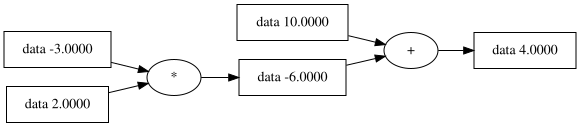

In [30]:
draw_dot(d)

In [31]:
class Value:

    # def __init__(self, data):
    # def __init__(self, data, _children=()):
    # def __init__(self, data, _children=(), _op=""):
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        # out = Value(self.data + other.data, (self, other))
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        # out = Value(self.data * other.data, (self, other))
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
d

Value(data=4.0)

In [32]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f }" % (n.label, n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


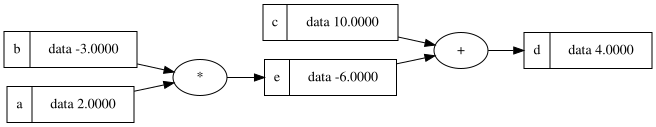

In [34]:
draw_dot(d)

In [37]:
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0)

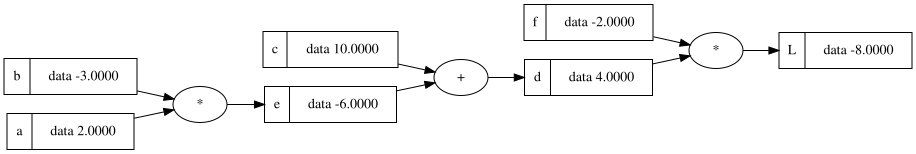

In [38]:
draw_dot(L)